In [18]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')

In [19]:
df = pd.read_excel('nutrients_2018dfo.xlsx',parse_dates=['dtUTC'],index_col=0)
#df = df.drop_duplicates(subset=['Depth', 'folder_day'])

In [20]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [21]:
def make_filename(path_run,folder, var='biol_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict"""
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(prefix, fname[0])

In [22]:
mask = xr.open_dataset('/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc')

In [23]:
#Make it easy to check values in the model finding the box and folder
df['folder_day'] = df['dtUTC'].dt.strftime('%d%b%y').str.lower()
jj = []
ii = []
dd = []
za = []
zb = []
for row in df.itertuples(index=False):
    j,i = finder(row.Lat,row.Lon)
    jj.append(j)
    ii.append(i)
    if row.Depth >= 0 and j>0:
        diff = mask.gdept_0[0,:,j,i].values - row.Depth
        dd.append(diff[diff<0].argmax())
        za.append(mask.gdept_0[0,:,j,i].values[dd[-1]])
        zb.append(mask.gdept_0[0,:,j,i].values[dd[-1]+1])
    else:
        dd.append('NaN')
        za.append('NaN')
        zb.append('NaN')
    
df['j'] = jj
df['i'] = ii
df['k_above'] = dd
df['z_above'] = za
df['z_bellow'] = zb

In [24]:
def interp_depth(N_shallow, N_deep, z_shallow, z_deep, z_obs):
    return N_shallow + (N_deep - N_shallow) * (z_obs - z_shallow) / (z_deep - z_shallow)

In [25]:
#This is done using the .py since it takes a while
# path = '/home/jvalenti/scratch/run_SHEM/SHEM18/'
# N_model = []
# for row in df.itertuples(index=False):
#     try:
#         fn = make_filename(path,row.folder_day)
#     except FileNotFoundError:
#         continue
#     if row.k_above == 'NaN':
#         N_model.append('NaN')
#     else:
#         ab = xr.load_dataset(fn)['nitrate'].isel(time_counter=0,deptht=row.k_above,y=row.j,x=row.i).item()
#         be = xr.load_dataset(fn)['nitrate'].isel(time_counter=0,deptht=row.k_above+1,y=row.j,x=row.i).item()
#         N_model.append(interp_depth(ab, be, row.z_above, row.z_bellow, row.Depth))
#     print(N_model[-1])
# df['N_model'] = N_model

In [26]:
runs = {'SSBase','SHEM18','diat_pref','exc_hbac','exc_hbac_2','growth_flag','growth_flag_2','mort_hbac','pred_flag','remin'}

In [27]:
dft = pd.read_excel('NO_model_remin.xlsx',parse_dates=['dtUTC'],index_col=0)

In [28]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()

    return rmse_val, bias

mask_N = dft.N_model!= 0 & ~dft.N.isna()
rmse,bias = calculate_rmse_bias(dft.N[mask_N], dft.N_model[mask_N])

print(f"RMSE: {rmse}")
print(f"Bias: {bias}")

RMSE: 4.568931939425856
Bias: -1.1231236128671473


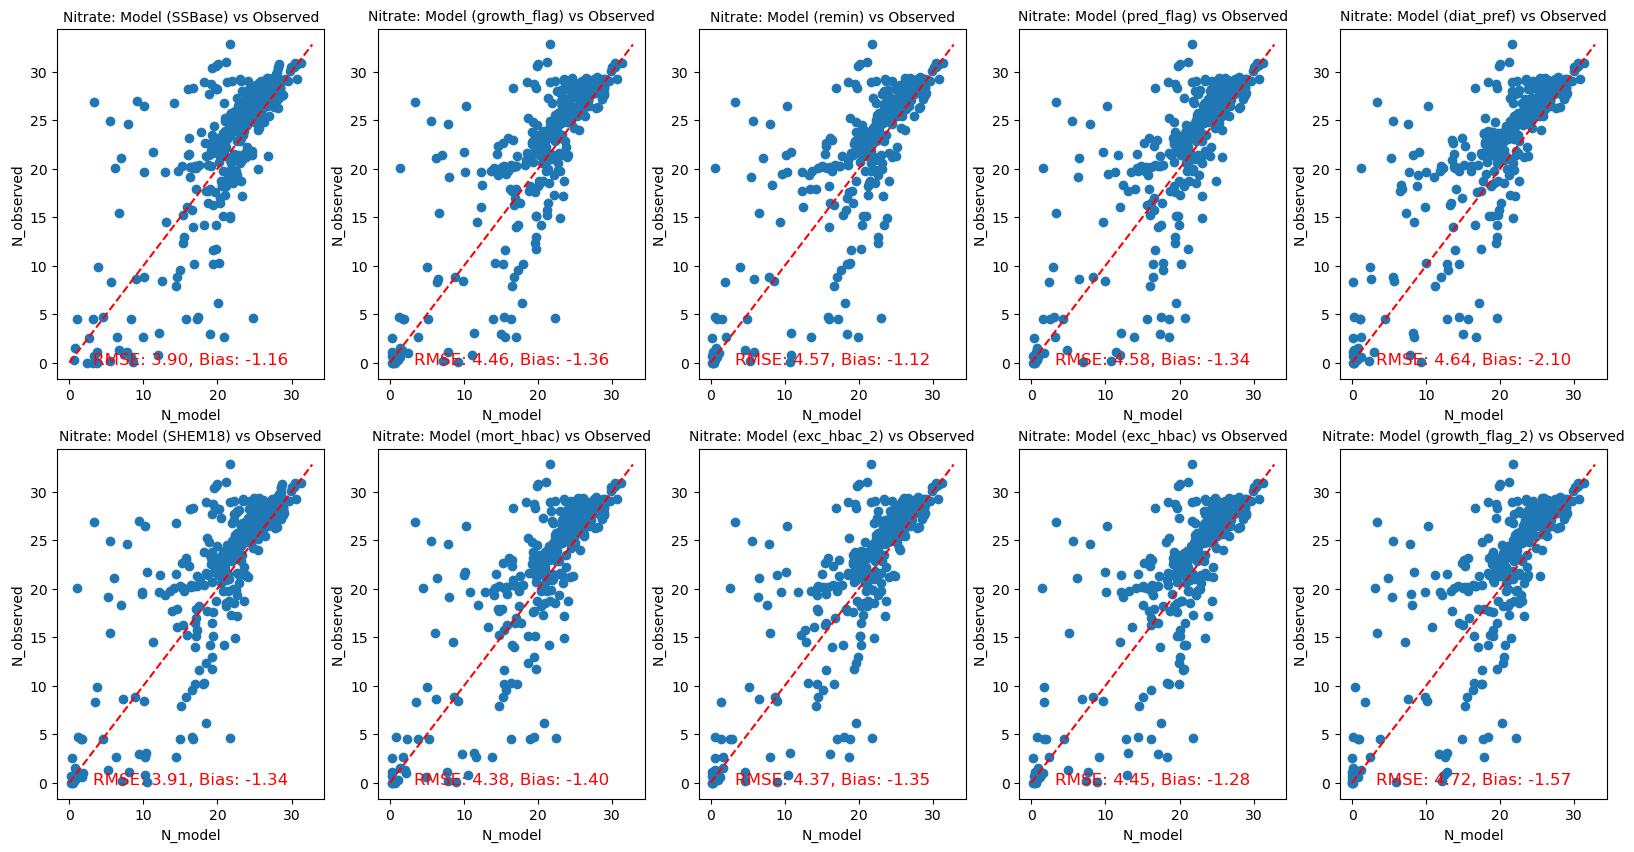

In [29]:
fig,axs = plt.subplots(2,5, figsize=(20,10))
axs = axs.flatten() 
for i,name in enumerate(runs):
    dft = pd.read_excel(f'NO_model_{name}.xlsx',parse_dates=['dtUTC'],index_col=0)
    mask_N = (dft.N_model!= 0) & (~dft.N.isna())
    rmse,bias = calculate_rmse_bias(dft.N[mask_N], dft.N_model[mask_N])
    axs[i].scatter(dft.N_model[mask_N],dft.N[mask_N])
    axs[i].set_xlabel('N_model')
    axs[i].set_ylabel('N_observed')
    axs[i].set_title(f'Nitrate: Model ({name}) vs Observed')
    axs[i].plot(np.linspace(0, max(dft.N_model[mask_N].max(), dft.N[mask_N].max()), 100), np.linspace(0, max(dft.N_model[mask_N].max(), dft.N[mask_N].max()), 100), 'r--') 
    axs[i].text(0.5, 0.04, f'RMSE: {rmse:.2f}, Bias: {bias:.2f}', ha='center', fontsize=12, transform=axs[i].transAxes,color='red')

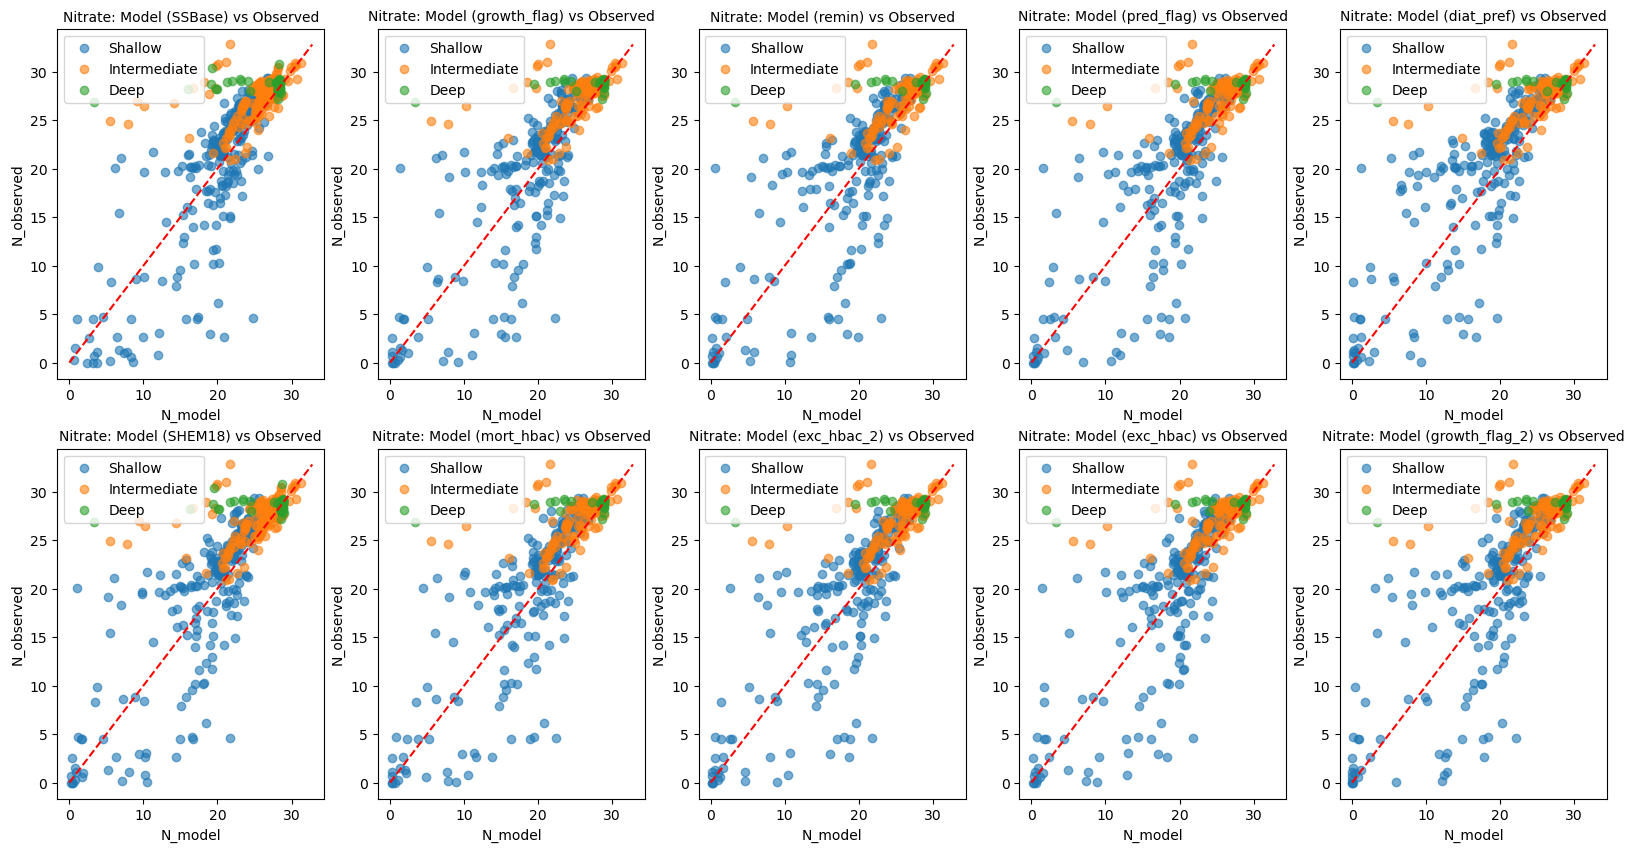

In [30]:
colors = {
    "Shallow": "blue",
    "Intermediate": "orange",
    "Deep": "green"
}

fig, axs = plt.subplots(2, 5, figsize=(20, 10))
axs = axs.flatten()

for i, name in enumerate(runs):
    dft = pd.read_excel(f'NO_model_{name}.xlsx', parse_dates=['dtUTC'], index_col=0)

    base_mask = (dft.N_model != 0) & (~dft.N.isna()) & (~dft.N_model.isna())

    depth_masks = {
        "Shallow": base_mask & (dft.Depth < 50),
        "Intermediate": base_mask & (dft.Depth.between(50, 200)),
        "Deep": base_mask & (dft.Depth > 200),
    }

    ax = axs[i]

    for label, mask in depth_masks.items():
        ax.scatter(
            dft.N_model[mask],
            dft.N[mask],
            label=label,
            alpha=0.6
        )

    max_val = max(dft.N_model[base_mask].max(), dft.N[base_mask].max())
    ax.plot([0, max_val], [0, max_val], 'r--')

    ax.set_title(f'Nitrate: Model ({name}) vs Observed')
    ax.set_xlabel('N_model')
    ax.set_ylabel('N_observed')
    ax.legend()

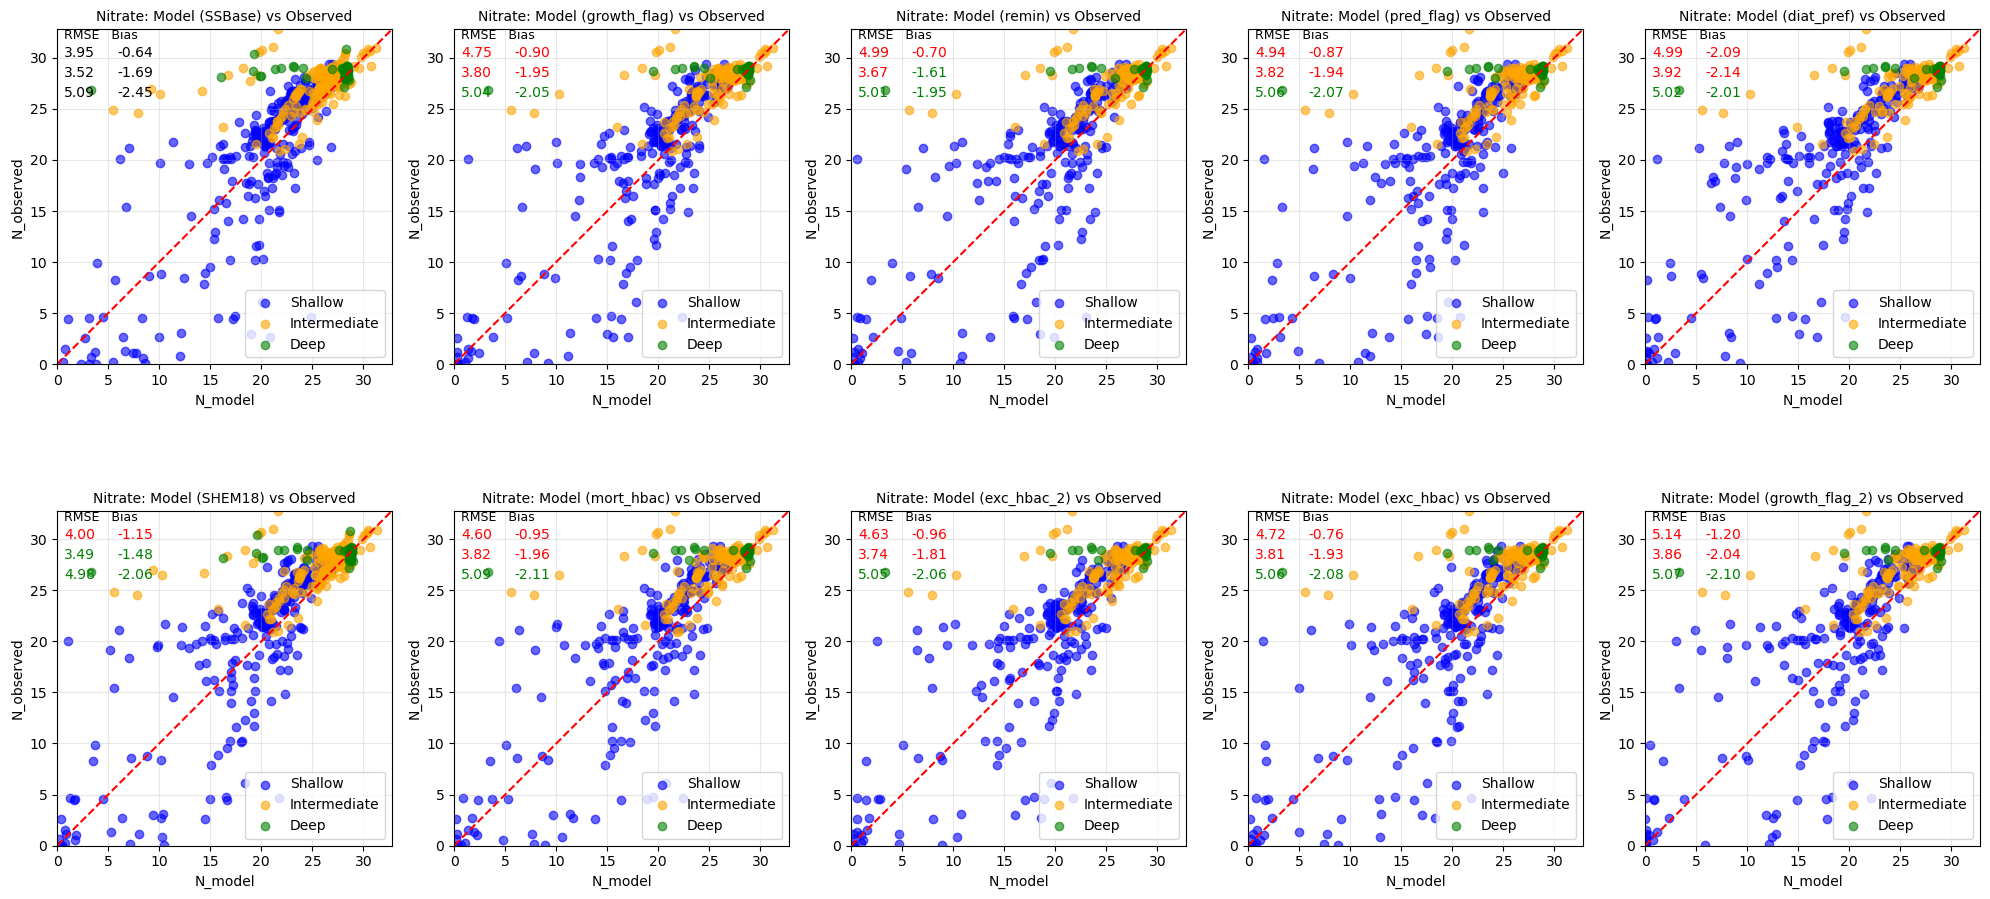

In [31]:
colors = {"Shallow": "blue", "Intermediate": "orange", "Deep": "green"}
depth_limits = [(0,50), (50,200), (200,np.inf)]
depth_labels = ["Shallow", "Intermediate", "Deep"]
tol = 1e-6 

dft_base = pd.read_excel('NO_model_SSBase.xlsx', parse_dates=['dtUTC'], index_col=0)
mask_base = (dft_base.N_model != 0) & (~dft_base.N.isna()) & (~dft_base.N_model.isna())
baseline_stats = []
for (dmin,dmax) in depth_limits:
    dm = mask_base & (dft_base.Depth.between(dmin, dmax, inclusive='left'))
    baseline_stats.append((calculate_rmse_bias(dft_base.N[dm], dft_base.N_model[dm]) 
                           if dm.any() else (np.nan,np.nan)))

fig, axs = plt.subplots(2, 5, figsize=(20,10))
axs = axs.flatten()

for i, name in enumerate(runs):
    dft = pd.read_excel(f'NO_model_{name}.xlsx', parse_dates=['dtUTC'], index_col=0)
    mask = (dft.N_model != 0) & (~dft.N.isna()) & (~dft.N_model.isna())
    stats = []

    for j, (label, (dmin,dmax)) in enumerate(zip(depth_labels, depth_limits)):
        dm = mask & (dft.Depth.between(dmin, dmax, inclusive='left'))
        if not dm.any():
            stats.append(("—","black","—","black"))
            continue

        ax = axs[i]
        ax.scatter(dft.N_model[dm], dft.N[dm], color=colors[label], alpha=0.6, label=label)
        rmse, bias = calculate_rmse_bias(dft.N[dm], dft.N_model[dm])
        base_rmse, base_bias = baseline_stats[j]

        if name == "SSBase":
            stats.append((f"{rmse:.2f}","black",f"{bias:.2f}","black"))
        else:
            stats.append((f"{rmse:.2f}", "green" if rmse <= base_rmse+tol else "red",
                          f"{bias:.2f}", "green" if abs(bias) <= abs(base_bias)+tol else "red"))

    if mask.any():
        max_val = max(dft.N_model[mask].max(), dft.N[mask].max())
        ax.plot([0,max_val],[0,max_val],'r--')
        ax.set_xlim(0,max_val); ax.set_ylim(0,max_val); ax.set_aspect('equal', adjustable='box')

    # Labels & stats
    ax.set_title(f'Nitrate: Model ({name}) vs Observed')
    ax.set_xlabel('N_model'); ax.set_ylabel('N_observed'); ax.legend(loc=4)
    ax.text(0.02,0.97,"RMSE   Bias", transform=ax.transAxes, fontsize=9)
    y=0.95
    for rmse_txt, rmse_col, bias_txt, bias_col in stats:
        ax.text(0.02,y,rmse_txt,color=rmse_col,fontsize=10,transform=ax.transAxes,va='top')
        ax.text(0.18,y,bias_txt,color=bias_col,fontsize=10,transform=ax.transAxes,va='top')
        y -= 0.06
    ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()